# VGGT-Omega PyTorch vs JAX Inference Comparison
This script/notebook runs both PyTorch and JAX versions of the VGGT-Omega 1B 512 model on real images, compares their predictions, checks mathematical parity, and compares execution times.

In [1]:
import os
import glob
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

# Force JAX to use CPU backend (since host GPU driver mismatch prevents JAX CUDA init)
os.environ["JAX_PLATFORMS"] = "cpu"

import jax
import jax.numpy as jnp

from vggt_omega.models import VGGTOmega as PTModel
from vggt_omega.jax.models import VGGTOmega as JAXModel
from vggt_omega.jax.load_weights import load_checkpoint
from vggt_omega.utils.load_fn import load_and_preprocess_images
from vggt_omega.utils.pose_enc import encoding_to_camera

## 0. Download Dataset and Models (if not present)

In [2]:
import urllib.request
import zipfile

def download_file(url, filepath):
    if os.path.exists(filepath):
        print(f"File {filepath} already exists. Skipping download.")
        return
    print(f"Downloading {url} to {filepath}...")
    try:
        req = urllib.request.Request(
            url, 
            headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        )
        with urllib.request.urlopen(req) as response, open(filepath, 'wb') as out_file:
            chunk_size = 16 * 1024 * 1024  # 16 MB chunks
            while True:
                chunk = response.read(chunk_size)
                if not chunk:
                    break
                out_file.write(chunk)
        print(f"Successfully downloaded {filepath}.")
    except Exception as e:
        if os.path.exists(filepath):
            os.remove(filepath)
        print(f"Error downloading {filepath}: {e}")
        raise e

def unproject_depth_map_to_point_map(depth_map: np.ndarray, extrinsic: np.ndarray, intrinsic: np.ndarray) -> np.ndarray:
    depth = depth_map[..., 0]
    num_frames, height, width = depth.shape

    y, x = np.meshgrid(np.arange(height), np.arange(width), indexing="ij")
    x = np.broadcast_to(x[None], (num_frames, height, width))
    y = np.broadcast_to(y[None], (num_frames, height, width))

    fx = intrinsic[:, 0, 0][:, None, None]
    fy = intrinsic[:, 1, 1][:, None, None]
    cx = intrinsic[:, 0, 2][:, None, None]
    cy = intrinsic[:, 1, 2][:, None, None]

    camera_points = np.stack(
        [
            (x - cx) / fx * depth,
            (y - cy) / fy * depth,
            depth,
        ],
        axis=-1,
    )

    rotation = extrinsic[:, :3, :3]
    translation = extrinsic[:, :3, 3]
    return np.einsum(
        "sij,shwj->shwi",
        np.transpose(rotation, (0, 2, 1)),
        camera_points - translation[:, None, None, :],
    )

# Download dataset if not present
if not os.path.exists("nerf_real_360"):
    zip_path = "nerf_real_360.zip"
    download_file(
        "https://huggingface.co/datasets/1kaiser/NERF_360/resolve/main/nerf_real_360.zip?download=true", 
        zip_path
    )
    print("Extracting nerf_real_360.zip...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Extraction complete.")
else:
    print("Dataset directory nerf_real_360/ already exists.")

# Download models if not present
download_file(
    "https://huggingface.co/datasets/1kaiser/vggt-omega-jax/resolve/main/vggt_omega_1b_512.pt", 
    "vggt_omega_1b_512.pt"
)
download_file(
    "https://huggingface.co/datasets/1kaiser/vggt-omega-jax/resolve/main/vggt_omega_1b_512.msgpack.zst", 
    "vggt_omega_1b_512.msgpack.zst"
)

Dataset directory nerf_real_360/ already exists.
File vggt_omega_1b_512.pt already exists. Skipping download.
File vggt_omega_1b_512.msgpack.zst already exists. Skipping download.


## 1. Load and Preprocess Images
Load 2 images from the nerf real 360 pinecone dataset.

In [3]:
image_dir = "nerf_real_360/pinecone/images"
image_paths = sorted(glob.glob(os.path.join(image_dir, "*")))[:2]
print("Loading images:")
for p in image_paths:
    print(f"  - {os.path.basename(p)}")

# PyTorch preprocessing -> shape [B, T, C, H, W]
x_pt = load_and_preprocess_images(image_paths, image_resolution=512, patch_size=16)
x_pt = x_pt.unsqueeze(0)
print(f"Preprocessed PyTorch shape: {x_pt.shape}")

# JAX preprocessing -> shape [B, T, H, W, C]
x_jax = jnp.array(x_pt.permute(0, 1, 3, 4, 2).numpy())
print(f"Preprocessed JAX shape: {x_jax.shape}")

Loading images:
  - IMG_7238.JPG
  - IMG_7239.JPG


Preprocessed PyTorch shape: torch.Size([1, 2, 3, 448, 592])
Preprocessed JAX shape: (1, 2, 448, 592, 3)


## 2. PyTorch Inference

In [4]:
print("Initializing PyTorch model...")
pt_model = PTModel(
    patch_size=16,
    embed_dim=1024,
    enable_camera=True,
    enable_depth=True,
    enable_alignment=False
).eval()

pt_state_dict = torch.load("vggt_omega_1b_512.pt", map_location="cpu")
if "model" in pt_state_dict:
    pt_state_dict = pt_state_dict["model"]
pt_model.load_state_dict(pt_state_dict, strict=True)

print("Running PyTorch CPU Inference...")
t0 = time.time()
with torch.no_grad():
    pt_preds = pt_model(x_pt)
pt_time = time.time() - t0
print(f"PyTorch CPU inference completed in {pt_time:.4f} seconds")

Initializing PyTorch model...


Running PyTorch CPU Inference...


PyTorch CPU inference completed in 4.5411 seconds


## 3. JAX Inference

In [5]:
print("Initializing JAX model...")
jax_model = JAXModel(
    patch_size=16,
    embed_dim=1024,
    enable_camera=True,
    enable_depth=True,
    enable_alignment=False
)

variables_template = jax_model.init(jax.random.PRNGKey(0), jnp.zeros((1, len(image_paths), 512, 512, 3)))
restored_params = load_checkpoint(variables_template, "vggt_omega_1b_512.msgpack.zst")

@jax.jit
def jax_predict(params, x):
    return jax_model.apply(params, x)

print("Compiling JAX model (first run)...")
t0 = time.time()
jax_preds = jax_predict(restored_params, x_jax)
for k, v in jax_preds.items():
    if isinstance(v, jnp.ndarray):
        v.block_until_ready()
jax_compile_time = time.time() - t0
print(f"JAX CPU first run (compile + inference) completed in {jax_compile_time:.4f} seconds")

print("Running JAX compiled inference (second run)...")
t0 = time.time()
jax_preds = jax_predict(restored_params, x_jax)
for k, v in jax_preds.items():
    if isinstance(v, jnp.ndarray):
        v.block_until_ready()
jax_jit_time = time.time() - t0
print(f"JAX CPU compiled inference completed in {jax_jit_time:.4f} seconds")

Initializing JAX model...


Compiling JAX model (first run)...


JAX CPU first run (compile + inference) completed in 26.1983 seconds
Running JAX compiled inference (second run)...


JAX CPU compiled inference completed in 18.9997 seconds


## 4. Output Parity Verification

In [6]:
print("--- Verifying Output Parity ---")
keys = ["camera_and_register_tokens", "pose_enc", "depth", "depth_conf"]
all_passed = True

for key in keys:
    pt_val = pt_preds[key]
    if isinstance(pt_val, torch.Tensor):
        pt_val = pt_val.cpu().numpy()
    jax_val = np.array(jax_preds[key])
    
    diff = np.max(np.abs(pt_val - jax_val))
    mean_diff = np.mean(np.abs(pt_val - jax_val))
    
    status = "PASSED" if diff < 1e-3 else "FAILED"
    if status == "FAILED":
        all_passed = False
        
    print(f"{key}:")
    print(f"  Shape: {pt_val.shape}")
    print(f"  Max Absolute Difference: {diff:.6e}")
    print(f"  Mean Absolute Difference: {mean_diff:.6e}")
    print(f"  Status: {status}")

if all_passed:
    print("\nSUCCESS: All outputs match within the 1e-3 threshold!")
else:
    print("\nFAIL: Parity mismatch detected!")

--- Verifying Output Parity ---
camera_and_register_tokens:
  Shape: (1, 2, 17, 2048)
  Max Absolute Difference: 5.340576e-05
  Mean Absolute Difference: 1.999295e-06
  Status: PASSED
pose_enc:
  Shape: (1, 2, 9)
  Max Absolute Difference: 1.192093e-07
  Mean Absolute Difference: 3.231172e-08
  Status: PASSED
depth:
  Shape: (1, 2, 448, 592, 1)
  Max Absolute Difference: 9.059906e-06
  Mean Absolute Difference: 5.387419e-07
  Status: PASSED
depth_conf:
  Shape: (1, 2, 448, 592)
  Max Absolute Difference: 3.252029e-04
  Mean Absolute Difference: 2.490888e-05
  Status: PASSED

SUCCESS: All outputs match within the 1e-3 threshold!


## 5. Visualize Results

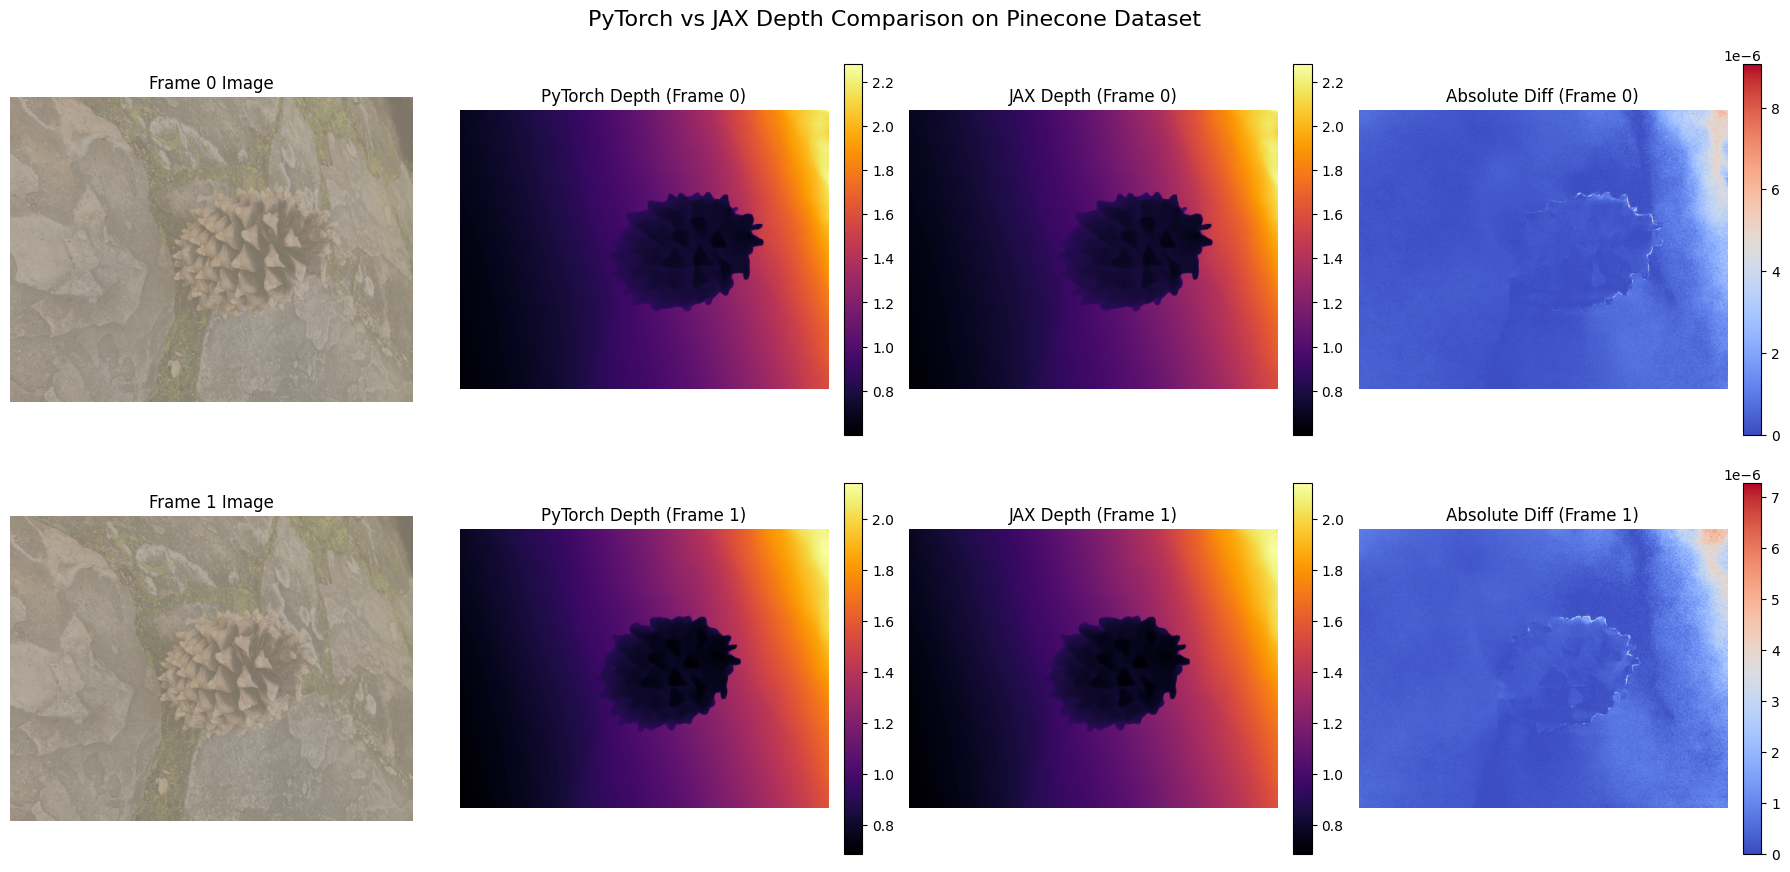

Saved comparison plot to parity_comparison.png


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i in range(2):
    # Original Image
    img_np = (x_jax[0, i] * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Frame {i} Image")
    axes[i, 0].axis("off")
    
    # PyTorch Depth
    im_pt = axes[i, 1].imshow(pt_preds["depth"][0, i, ..., 0].cpu().numpy(), cmap="inferno")
    axes[i, 1].set_title(f"PyTorch Depth (Frame {i})")
    axes[i, 1].axis("off")
    fig.colorbar(im_pt, ax=axes[i, 1], fraction=0.046, pad=0.04)
    
    # JAX Depth
    im_jax = axes[i, 2].imshow(jax_preds["depth"][0, i, ..., 0], cmap="inferno")
    axes[i, 2].set_title(f"JAX Depth (Frame {i})")
    axes[i, 2].axis("off")
    fig.colorbar(im_jax, ax=axes[i, 2], fraction=0.046, pad=0.04)
    
    # Difference Map
    diff_depth = np.abs(pt_preds["depth"][0, i, ..., 0].cpu().numpy() - jax_preds["depth"][0, i, ..., 0])
    im_diff = axes[i, 3].imshow(diff_depth, cmap="coolwarm")
    axes[i, 3].set_title(f"Absolute Diff (Frame {i})")
    axes[i, 3].axis("off")
    fig.colorbar(im_diff, ax=axes[i, 3], fraction=0.046, pad=0.04)

plt.suptitle("PyTorch vs JAX Depth Comparison on Pinecone Dataset", fontsize=16)
plt.tight_layout()
plt.savefig("parity_comparison.png", dpi=150)
plt.show()
print("Saved comparison plot to parity_comparison.png")

## 6. 3D Reconstruction Orthographic View Comparison

Processing 3D point cloud projections...


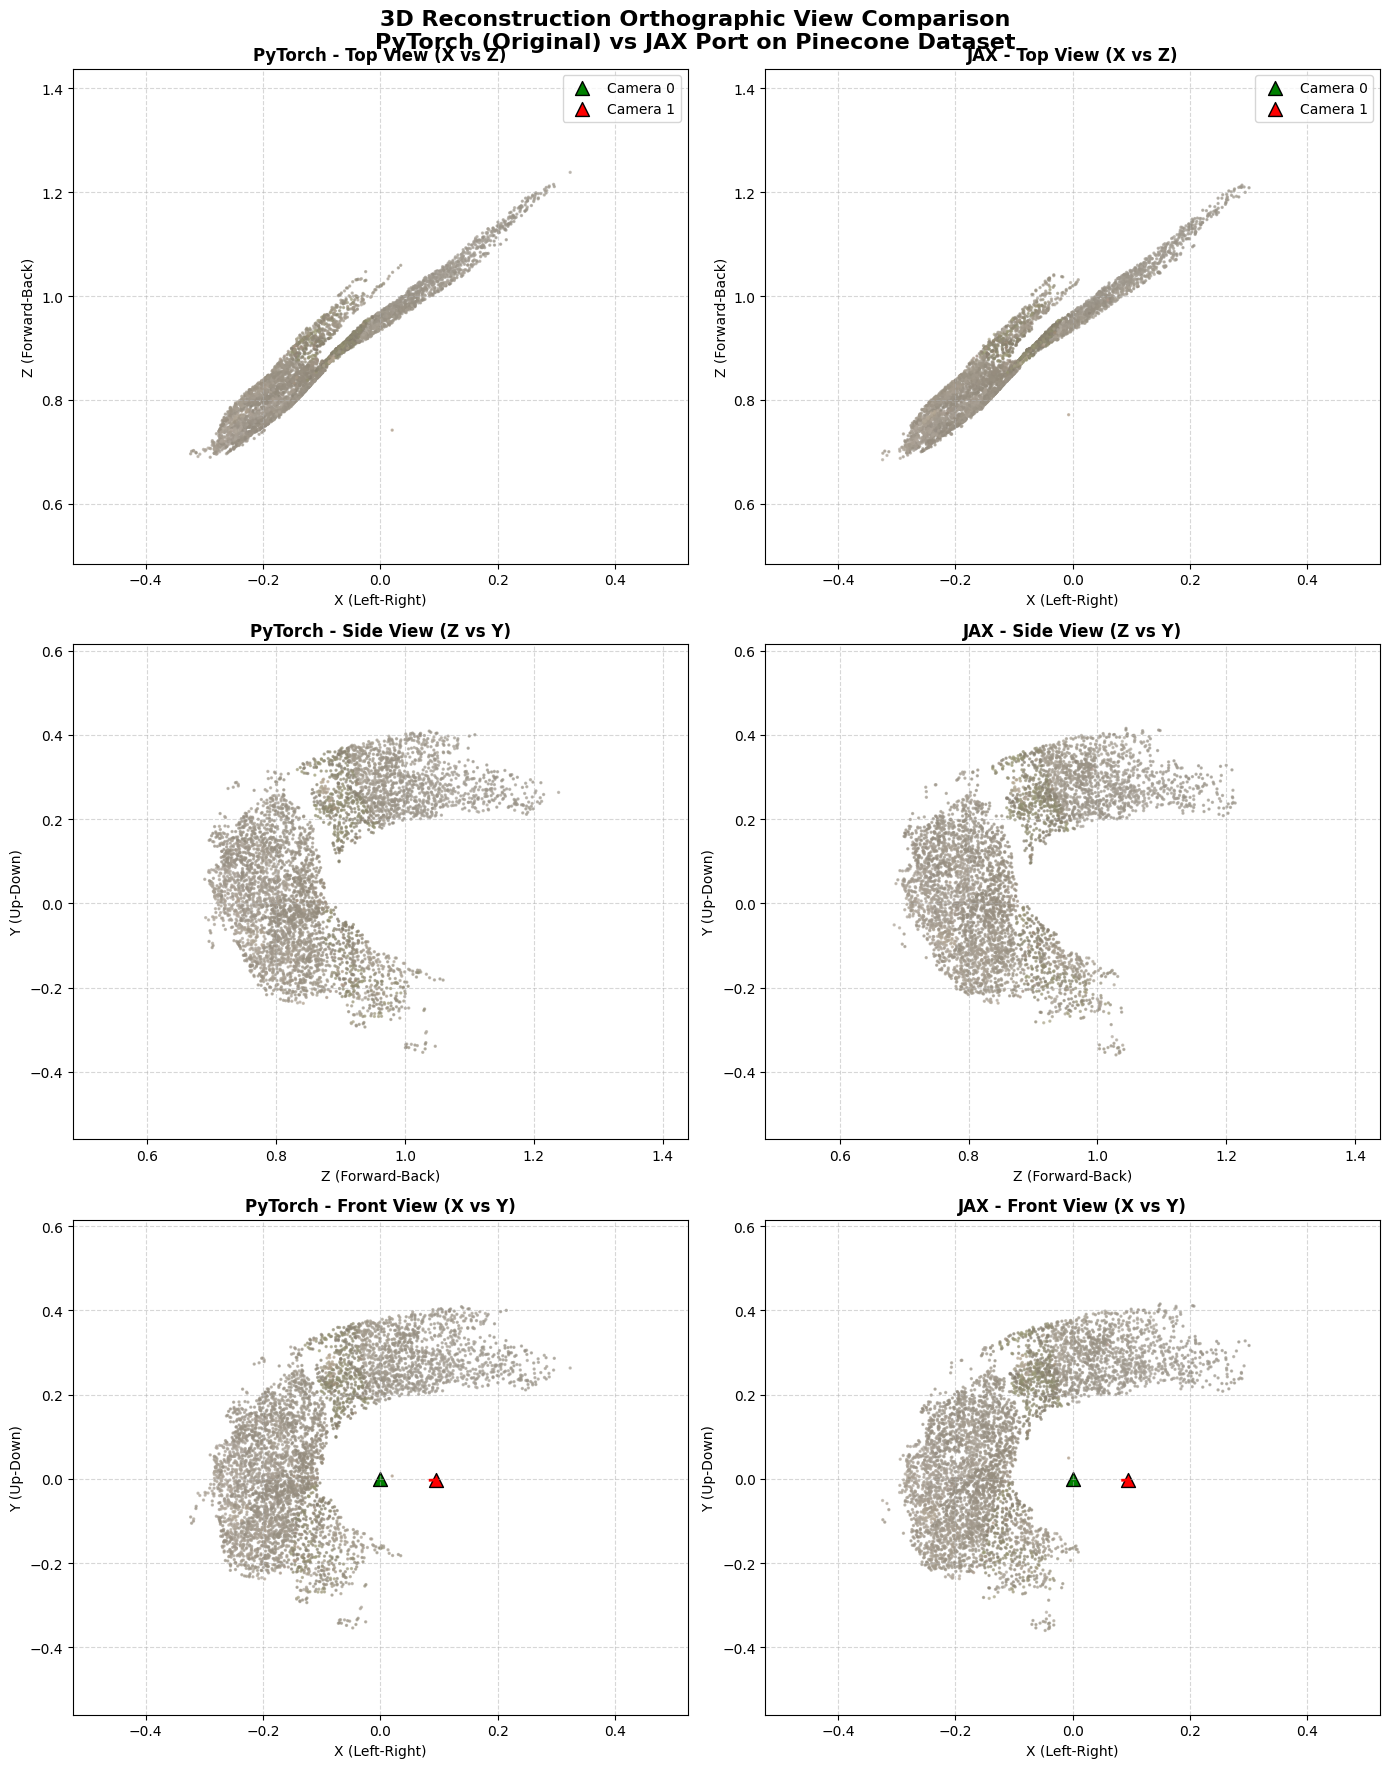

Saved 3D views comparison to views_comparison.png


In [8]:
print("Processing 3D point cloud projections...")

# Decode camera parameters
pt_extrinsic, pt_intrinsic = encoding_to_camera(
    pt_preds["pose_enc"],
    pt_preds["images"].shape[-2:],
)
pt_extrinsic_np = pt_extrinsic.detach().cpu().numpy()[0]
pt_intrinsic_np = pt_intrinsic.detach().cpu().numpy()[0]
pt_depth_np = pt_preds["depth"].detach().cpu().numpy()[0]
pt_conf_np = pt_preds["depth_conf"].detach().cpu().numpy()[0]
pt_images_np = pt_preds["images"].detach().cpu().numpy()[0]

pt_world_points = unproject_depth_map_to_point_map(pt_depth_np, pt_extrinsic_np, pt_intrinsic_np)

# Decode JAX camera parameters (convert pose_enc from numpy/jax array to torch tensor first)
jax_pose_enc_torch = torch.from_numpy(np.array(jax_preds["pose_enc"]))
jax_extrinsic, jax_intrinsic = encoding_to_camera(
    jax_pose_enc_torch,
    pt_preds["images"].shape[-2:],
)
jax_extrinsic_np = jax_extrinsic.numpy()[0]
jax_intrinsic_np = jax_intrinsic.numpy()[0]
jax_depth_np = np.array(jax_preds["depth"])[0]
jax_conf_np = np.array(jax_preds["depth_conf"])[0]

jax_world_points = unproject_depth_map_to_point_map(jax_depth_np, jax_extrinsic_np, jax_intrinsic_np)

# Preprocess colors (PyTorch format -> channels_last [0, 1])
colors_np = np.transpose(pt_images_np, (0, 2, 3, 1))
colors_np = (colors_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)

def process_run(world_points, extrinsics, confidence, colors):
    T = extrinsics.shape[0]
    ext4x4 = np.zeros((T, 4, 4))
    ext4x4[:, :3, :4] = extrinsics
    ext4x4[:, 3, 3] = 1.0
    
    R0 = ext4x4[0, :3, :3]
    t0 = ext4x4[0, :3, 3]
    
    # Transform points to Cam0 frame: P_c0 = R0 * P_w + t0
    points_c0 = np.einsum("ij,thwj->thwi", R0, world_points) + t0[None, None, None, :]
    
    # Transform camera positions to Cam0 frame
    cam_centers_c0 = []
    cam_dirs_c0 = []
    for i in range(T):
        Ri = ext4x4[i, :3, :3]
        ti = ext4x4[i, :3, 3]
        Cw = -Ri.T @ ti
        Cc0 = R0 @ Cw + t0
        
        Di_w = Ri[2, :] # 3rd row of Ri (OpenCV optical axis Z-axis)
        Di_c0 = R0 @ Di_w
        
        cam_centers_c0.append(Cc0)
        cam_dirs_c0.append(Di_c0)
        
    cam_centers_c0 = np.array(cam_centers_c0)
    cam_dirs_c0 = np.array(cam_dirs_c0)
    
    # Filter point cloud using confidence
    flat_points = points_c0.reshape(-1, 3)
    flat_conf = confidence.reshape(-1)
    flat_colors = colors.reshape(-1, 3)
    
    valid_mask = np.isfinite(flat_points).all(axis=-1)
    flat_points = flat_points[valid_mask]
    flat_conf = flat_conf[valid_mask]
    flat_colors = flat_colors[valid_mask]
    
    if len(flat_conf) > 0:
        thres = np.percentile(flat_conf, 85)
        mask = flat_conf >= thres
        flat_points = flat_points[mask]
        flat_colors = flat_colors[mask]
        
    if len(flat_points) > 5000:
        idx = np.random.choice(len(flat_points), 5000, replace=False)
        flat_points = flat_points[idx]
        flat_colors = flat_colors[idx]
        
    return flat_points, flat_colors, cam_centers_c0, cam_dirs_c0

pt_pts, pt_clrs, pt_cams, pt_dirs = process_run(pt_world_points, pt_extrinsic_np, pt_conf_np, colors_np)
jax_pts, jax_clrs, jax_cams, jax_dirs = process_run(jax_world_points, jax_extrinsic_np, jax_conf_np, colors_np)

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

views = [
    ("Top View (X vs Z)", 0, 2, "X (Left-Right)", "Z (Forward-Back)", False),
    ("Side View (Z vs Y)", 2, 1, "Z (Forward-Back)", "Y (Up-Down)", True),
    ("Front View (X vs Y)", 0, 1, "X (Left-Right)", "Y (Up-Down)", True)
]

for row, (view_title, d1, d2, l1, l2, inv_y) in enumerate(views):
    # PyTorch Column
    ax_pt = axes[row, 0]
    ax_pt.scatter(pt_pts[:, d1], pt_pts[:, d2], c=pt_clrs, s=2, alpha=0.6)
    
    colors_cam = ["green", "red"]
    for idx in range(len(pt_cams)):
        c_pos = pt_cams[idx]
        c_dir = pt_dirs[idx]
        ax_pt.scatter(c_pos[d1], c_pos[d2], c=colors_cam[idx], marker="^", s=100, edgecolors="black", label=f"Camera {idx}" if row==0 else "")
        ax_pt.plot([c_pos[d1], c_pos[d1] + 0.15 * c_dir[d1]], [c_pos[d2], c_pos[d2] + 0.15 * c_dir[d2]], color=colors_cam[idx], linewidth=2)
        
    ax_pt.set_title(f"PyTorch - {view_title}", fontsize=12, fontweight="bold")
    ax_pt.set_xlabel(l1)
    ax_pt.set_ylabel(l2)
    ax_pt.grid(True, linestyle="--", alpha=0.5)
    if inv_y:
        ax_pt.invert_yaxis()
    if row == 0:
        ax_pt.legend()
        
    # JAX Column
    ax_jax = axes[row, 1]
    ax_jax.scatter(jax_pts[:, d1], jax_pts[:, d2], c=jax_clrs, s=2, alpha=0.6)
    
    for idx in range(len(jax_cams)):
        c_pos = jax_cams[idx]
        c_dir = jax_dirs[idx]
        ax_jax.scatter(c_pos[d1], c_pos[d2], c=colors_cam[idx], marker="^", s=100, edgecolors="black", label=f"Camera {idx}" if row==0 else "")
        ax_jax.plot([c_pos[d1], c_pos[d1] + 0.15 * c_dir[d1]], [c_pos[d2], c_pos[d2] + 0.15 * c_dir[d2]], color=colors_cam[idx], linewidth=2)
        
    ax_jax.set_title(f"JAX - {view_title}", fontsize=12, fontweight="bold")
    ax_jax.set_xlabel(l1)
    ax_jax.set_ylabel(l2)
    ax_jax.grid(True, linestyle="--", alpha=0.5)
    if inv_y:
        ax_jax.invert_yaxis()
    if row == 0:
        ax_jax.legend()
        
    min_d1 = min(pt_pts[:, d1].min(), jax_pts[:, d1].min()) - 0.2
    max_d1 = max(pt_pts[:, d1].max(), jax_pts[:, d1].max()) + 0.2
    min_d2 = min(pt_pts[:, d2].min(), jax_pts[:, d2].min()) - 0.2
    max_d2 = max(pt_pts[:, d2].max(), jax_pts[:, d2].max()) + 0.2
    
    ax_pt.set_xlim(min_d1, max_d1)
    ax_pt.set_ylim(min_d2, max_d2)
    ax_jax.set_xlim(min_d1, max_d1)
    ax_jax.set_ylim(min_d2, max_d2)

plt.suptitle("3D Reconstruction Orthographic View Comparison\nPyTorch (Original) vs JAX Port on Pinecone Dataset", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("views_comparison.png", dpi=150)
plt.show()
print("Saved 3D views comparison to views_comparison.png")